In [33]:
# Импорты
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, StackingClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

In [34]:
# Загрузка датасета
dataset  = pd.read_csv('heart.csv')
dataset.info()
dataset.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [35]:
# Подготовка датасета

#Преобразование категориальных переменных
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
cat_col = dataset.select_dtypes(include=['object']).columns
encoded_data = encoder.fit_transform(dataset[cat_col])

# датасет с преобразованными данными
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(cat_col))
dataset_numeric = dataset.select_dtypes(exclude=['object'])
dataset_processed = pd.concat([dataset_numeric, encoded_df], axis=1)

print("Объединенный датасет:\n")
display(dataset_processed.head())

Объединенный датасет:



,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
1,49,160,180,0,156,1.0,1,1.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,37,130,283,0,98,0.0,0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
3,48,138,214,0,108,1.5,1,1.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
4,54,150,195,0,122,0.0,0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0


/tmp/ipykernel_6059/928269925.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='HeartDisease', data=dataset_processed, palette='viridis')


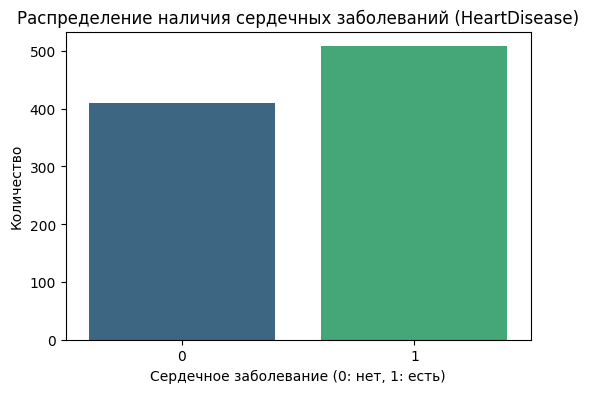

In [36]:
# Распределение целевой переменной HeartDisease
plt.figure(figsize=(6, 4))
sns.countplot(x='HeartDisease', data=dataset_processed, palette='viridis')
plt.title('Распределение наличия сердечных заболеваний (HeartDisease)')
plt.xlabel('Сердечное заболевание (0: нет, 1: есть)')
plt.ylabel('Количество')
plt.show()


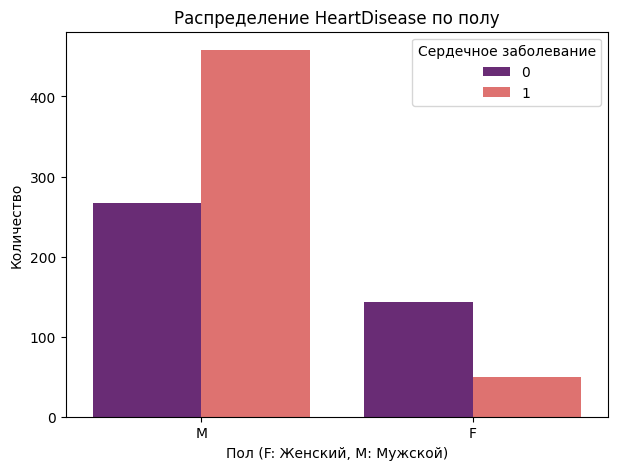

In [37]:
# Распределение HeartDisease по полу (Sex)
plt.figure(figsize=(7, 5))
sns.countplot(x='Sex', hue='HeartDisease', data=dataset, palette='magma')
plt.title('Распределение HeartDisease по полу')
plt.xlabel('Пол (F: Женский, M: Мужской)')
plt.ylabel('Количество')
plt.legend(title='Сердечное заболевание')
plt.show()


In [38]:
# Разбивка датасета на обучающее и тестовое множество
y = dataset_processed['HeartDisease']
X = dataset_processed.drop(['HeartDisease'], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

In [39]:
# Функция для обучения модели и вывода метрик
def fit_model(X_train, X_test, y_train, y_test, model):
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  print (f'метрики для {str(model)}')
  print(classification_report(y_test, y_pred), '\n')
  return model

# Дерево решений
dtc_model = fit_model(X_train, X_test, y_train, y_test, DecisionTreeClassifier(random_state=RANDOM_STATE))

# Случайный лес
rfc_model = fit_model(X_train, X_test, y_train, y_test, RandomForestClassifier(random_state=RANDOM_STATE))


метрики для DecisionTreeClassifier(random_state=42)
              precision    recall  f1-score   support

           0       0.73      0.83      0.78        77
           1       0.86      0.78      0.82       107

    accuracy                           0.80       184
   macro avg       0.80      0.80      0.80       184
weighted avg       0.81      0.80      0.80       184
 

метрики для RandomForestClassifier(random_state=42)
              precision    recall  f1-score   support

           0       0.85      0.87      0.86        77
           1       0.90      0.89      0.90       107

    accuracy                           0.88       184
   macro avg       0.88      0.88      0.88       184
weighted avg       0.88      0.88      0.88       184
 



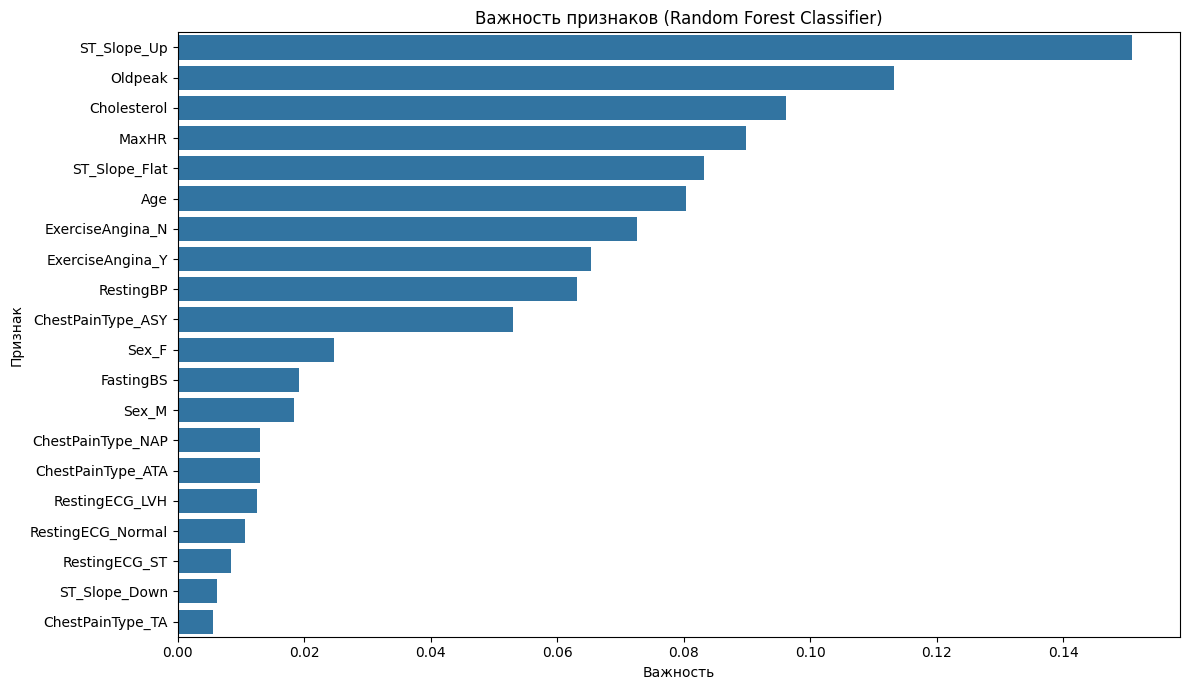

In [40]:
# Важность признаков
importances = rfc_model.feature_importances_
feature_names = X_train.columns

feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Важность признаков (Random Forest Classifier)')
plt.xlabel('Важность')
plt.ylabel('Признак')
plt.tight_layout()
plt.show()

In [41]:
# Бэггинг для дерева решений
bg_model = fit_model(X_train, X_test, y_train, y_test, BaggingClassifier(random_state=RANDOM_STATE))


метрики для BaggingClassifier(random_state=42)
              precision    recall  f1-score   support

           0       0.79      0.91      0.84        77
           1       0.93      0.82      0.87       107

    accuracy                           0.86       184
   macro avg       0.86      0.87      0.86       184
weighted avg       0.87      0.86      0.86       184
 



In [42]:
# Cтаккинг с final estimator = LogisticRegression
stack_model = fit_model(X_train, X_test, y_train, y_test,
                        StackingClassifier(estimators=[('dtc', dtc_model), ('rfc', rfc_model), ('svc', LinearSVC(random_state=RANDOM_STATE, dual=False))]))

метрики для StackingClassifier(estimators=[('dtc', DecisionTreeClassifier(random_state=42)),
                               ('rfc', RandomForestClassifier(random_state=42)),
                               ('svc', LinearSVC(dual=False, random_state=42))])
              precision    recall  f1-score   support

           0       0.82      0.87      0.84        77
           1       0.90      0.86      0.88       107

    accuracy                           0.86       184
   macro avg       0.86      0.86      0.86       184
weighted avg       0.87      0.86      0.86       184
 



In [43]:
# Cтаккинг с final estimator = DecisionTreeClassifier
stack_model = fit_model(X_train, X_test, y_train, y_test,
                        StackingClassifier(estimators=[('dtc', dtc_model), ('rfc', rfc_model), ('svc', LinearSVC(random_state=RANDOM_STATE, dual=False))],
                        final_estimator=DecisionTreeClassifier(random_state=RANDOM_STATE)))

метрики для StackingClassifier(estimators=[('dtc', DecisionTreeClassifier(random_state=42)),
                               ('rfc', RandomForestClassifier(random_state=42)),
                               ('svc', LinearSVC(dual=False, random_state=42))],
                   final_estimator=DecisionTreeClassifier(random_state=42))
              precision    recall  f1-score   support

           0       0.67      0.79      0.73        77
           1       0.83      0.72      0.77       107

    accuracy                           0.75       184
   macro avg       0.75      0.76      0.75       184
weighted avg       0.76      0.75      0.75       184
 



## Выводы по проделанной работе


*   **Decision Tree Classifier**
    *   **Класс 0:** Precision: 0.73, Recall: 0.83, F1-score: 0.78
    *   **Класс 1:** Precision: 0.86, Recall: 0.78, F1-score: 0.82
    *   **Accuracy:** 0.80

*   **Random Forest Classifier**
    *   **Класс 0:** Precision: 0.85, Recall: 0.87, F1-score: 0.86
    *   **Класс 1:** Precision: 0.90, Recall: 0.89, F1-score: 0.90
    *   **Accuracy:** 0.88

*   **Bagging Classifier (с Decision Tree)**
    *   **Класс 0:** Precision: 0.79, Recall: 0.91, F1-score: 0.84
    *   **Класс 1:** Precision: 0.93, Recall: 0.82, F1-score: 0.87
    *   **Accuracy:** 0.86

*   **Stacking Classifier (с Logistic Regression в качестве финального оценщика)**
    *   **Класс 0:** Precision: 0.82, Recall: 0.87, F1-score: 0.84
    *   **Класс 1:** Precision: 0.90, Recall: 0.86, F1-score: 0.88
    *   **Accuracy:** 0.86

*   **Stacking Classifier (с Decision Tree в качестве финального оценщика)**
    *   **Класс 0:** Precision: 0.67, Recall: 0.79, F1-score: 0.73
    *   **Класс 1:** Precision: 0.83, Recall: 0.72, F1-score: 0.77
    *   **Accuracy:** 0.75

Исходя из всех метрик, **Random Forest Classifier** является наилучшей моделью. Она демонстрирует самые высокие значения `accuracy` (0.88), `precision`, `recall` и `f1-score` для обоих классов по сравнению со всеми остальными моделями. В частности, она показывает отличную сбалансированность между `precision` и `recall` для класса 1 (наличие сердечного заболевания), что крайне важно для медицинских диагнозов.

*   **Random Forest Classifier** превосходит одиночное дерево решений, что ожидаемо, поскольку он уменьшает переобучение за счет усреднения множества деревьев.
*   Он также немного лучше, чем `Bagging Classifier` и `Stacking Classifier` с `Logistic Regression` как финальным оценщиком, по общей точности и сбалансированности метрик.
*   `Stacking Classifier` с `Decision Tree` в качестве финального оценщика показал наихудшие результаты среди ансамблевых методов, что подчеркивает важность правильного выбора финального оценщика для стекинга.